In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [9]:
from niceplots import plot_selection

In [2]:
plt.style.use("~/nice.mplstyle")

In [7]:
nice_names = {
    "sp": "surface_pressure",
    "u10": "10m_zonal_wind",
    "v10": "10m_meridional_wind",
    "t2m": "2m_temperature",
    "sh2": "2m_specific humidity",
    "gh": "geopotential_height",
    "u": "zonal_wind",
    "v": "meridional_wind",
    "w": "vertical_velocity",
    "t": "temperature",
    "q": "specific_humidity",
}

In [18]:
metric = "rmse"
error = {}
for name in ["HRRR", "GFS"]:
    key = name.lower()
    xds = xr.open_dataset(
        f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/{key}-forecasts-vs-hrrr-analysis/trim25/{metric}.lam.nc",
        decode_timedelta=True,
    )
    xds = xds.sel(fhr=slice(49))
    for k in xds.data_vars: 
        if k in nice_names.keys():
            xds = xds.rename({k: nice_names[k]})
    error[name] = xds


/global/u2/t/timothys/nested-eagle/0.25deg-06km/baselines/niceplots.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])


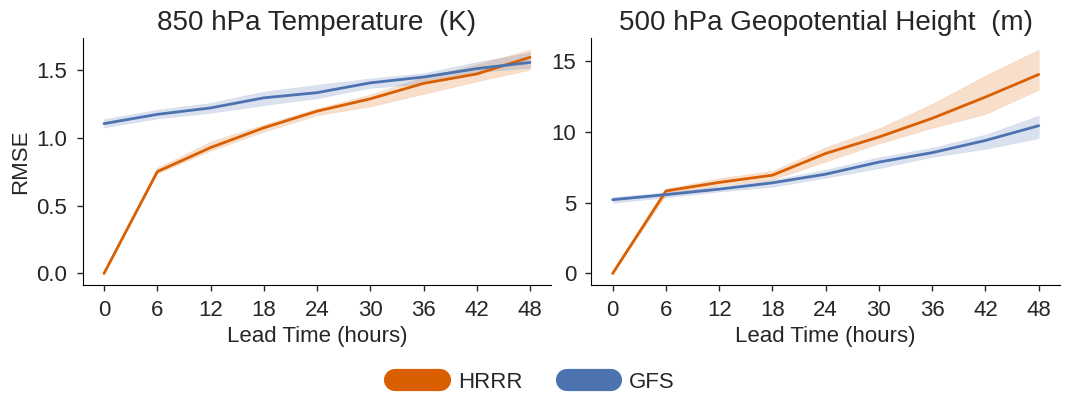

In [20]:
fig, axs = plot_selection(
    error,
    metric_name=metric.upper(),
    variables=[{"temperature": 850}, {"geopotential_height": 500}],
    nrows=1,
)
fig.savefig(f"supplemental-figures/analysis_error_example.pdf", bbox_inches="tight")
fig.savefig(f"supplemental-figures/analysis_error_example.jpeg", bbox_inches="tight", dpi=300)

/global/u2/t/timothys/nested-eagle/0.25deg-06km/baselines/niceplots.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])


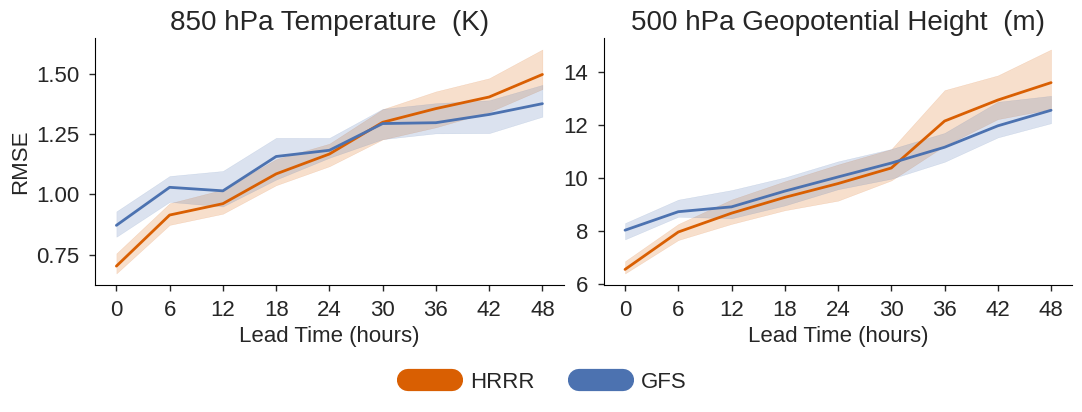

In [21]:
metric = "rmse"
valortest = "testing"
figdict = {}
for name in ["HRRR", "GFS"]:
    xds = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/{name.lower()}-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)
    xds = xds.sel(fhr=slice(49))
    figdict[name] = xds

fig, axs = plot_selection(
    figdict,
    metric_name=metric.upper(),
    variables=[{"temperature": 850}, {"geopotential_height": 500}],
    nrows=1,
)

fig.savefig(f"paper-figures/obs_error_example.pdf", bbox_inches="tight")
fig.savefig(f"paper-figures/obs_error_example.jpeg", bbox_inches="tight", dpi=300)